In [8]:
import pandas as pd
import numpy as np
import pymc as pm
import pymc.sampling_jax
import arviz as az

In [2]:
data_commune = pd.read_csv('data_commune.csv')
data_province = pd.read_csv('data_province.csv')

In [3]:
data_commune = pd.read_csv('data_commune.csv')

In [4]:
data_commune.head()

,Start Date,Province,Commune Rurale,Susceptible,Cases,Deaths,Killed and Disposed of,Slaughtered/ Killed for commercial use
0,2008-06-12,Moulay Yacoub,Ain Chkef,40,40,6,34.0,0.0
1,2008-06-26,Benslimane,Sidi Bettache,500,32,16,0.0,0.0
2,2008-06-30,Al Hoceima,Moulay Ahmed Cherif,439,150,50,0.0,0.0
3,2008-06-30,Meknes,Ouislane,360,177,13,0.0,0.0
4,2008-06-30,Moulay Yacoub,Ain Kansra,470,18,8,0.0,0.0


In [6]:
# Convert data to numpy arrays
cases = np.array(data_commune["Cases"])
deaths = np.array(data_commune["Deaths"])

In [9]:
# Bayesian model for estimating CFR
with pm.Model() as cfr_model:
    # Prior for CFR (Beta distribution with alpha=2, beta=2 as a uniform prior, our prior belief is that CFR is around 0.5)
    cfr = pm.Beta("cfr", alpha=2, beta=2)

    # Likelihood (binomial distribution)
    deaths_obs = pm.Binomial("deaths_obs", n=cases, p=cfr, observed=deaths)

    # Sample from the posterior
    trace = pm.sampling.jax.sample_blackjax_nuts(draws=5000, tune=1000,chains= 4)


Compiling...
Compilation time = 0:00:10.610329
Sampling...
Sampling time = 0:00:03.454990
Transforming variables...
Transformation time = 0:00:00.076122


In [11]:
# Summary of the posterior distribution of CFR
summary = az.summary(trace, hdi_prob=0.95)
summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cfr,0.463,0.007,0.45,0.476,0.0,0.0,7549.0,10335.0,1.0


<Axes: title={'center': 'cfr'}>

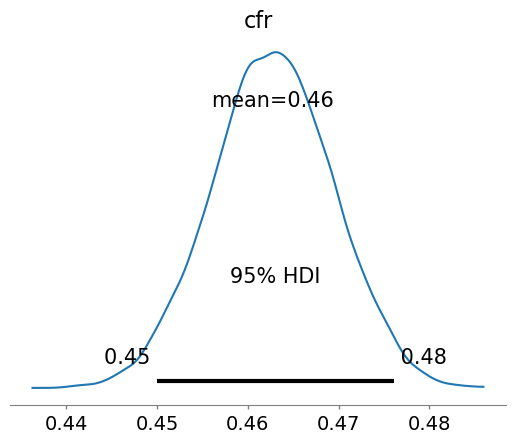

In [13]:
# Plot posterior distribution
az.plot_posterior(trace, var_names=["cfr"], hdi_prob=0.95)